In [13]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
dataset=pd.read_csv('slip_21.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values
print(dataset.isnull().sum())


6        0
148      0
72       0
35       0
0        0
33.6     0
0.627    0
50       0
1        0
dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [27]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [34]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
d=DecisionTreeClassifier(criterion='entropy',random_state=0)
d.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred=d.predict(X_test)

[[85 16]
 [23 30]]


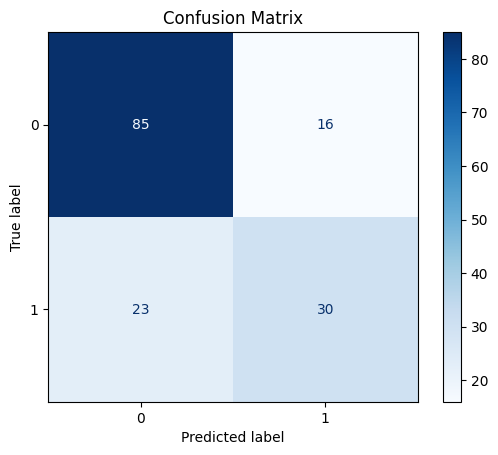

74.67532467532467
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       101
           1       0.65      0.57      0.61        53

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [36]:

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report
c=confusion_matrix(y_test,y_pred)
print(c)
disp=ConfusionMatrixDisplay(c)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

acc=accuracy_score(y_test,y_pred)*100
print(acc)
print(classification_report(y_test,y_pred))


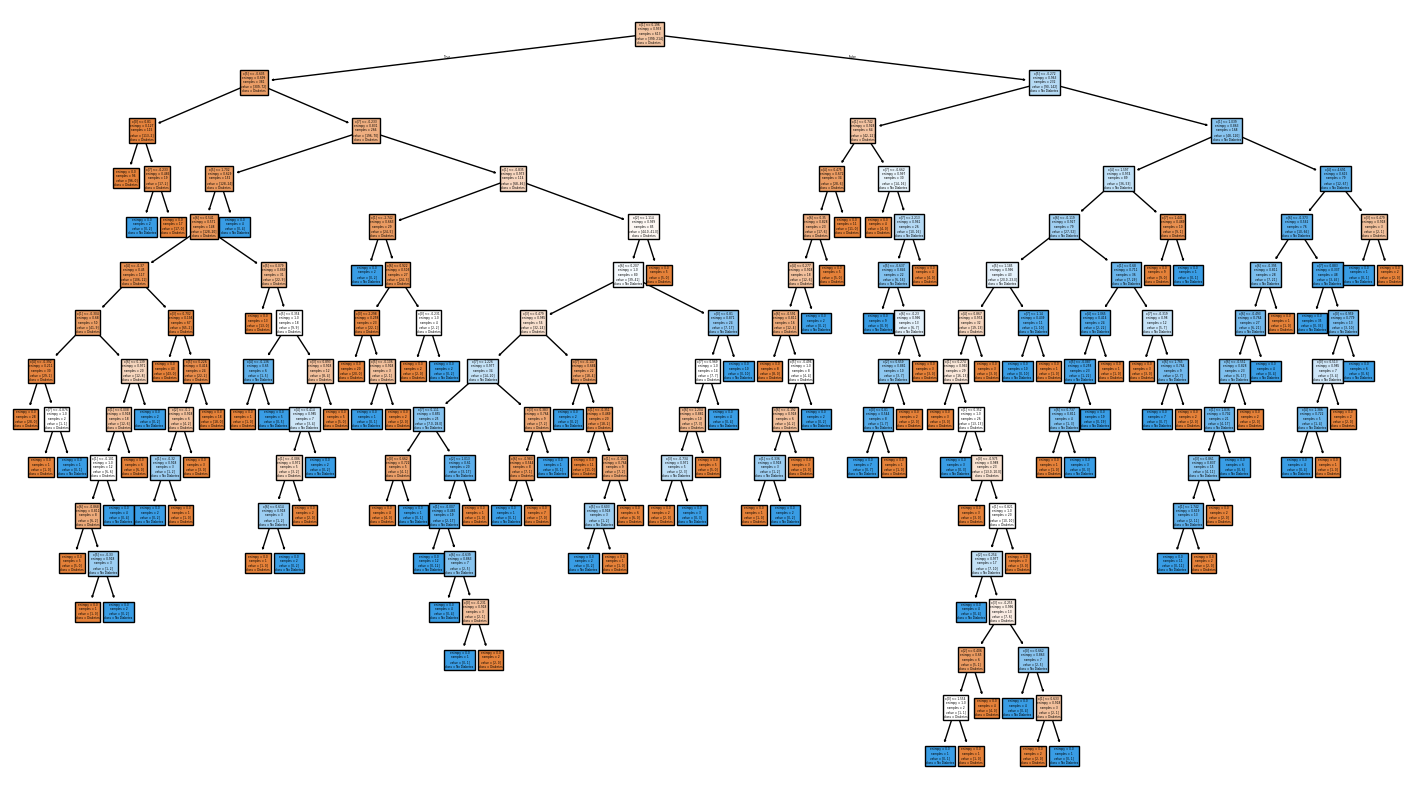

In [37]:
#from sklearn import tree
plt.figure(figsize=(18,10))
plot_tree(d,filled=True,class_names=['Diabetes','No Diabetes'])
plt.show()

In [41]:
s=[[1,89,66,23,94,28.1,0.167,21]]
sample_scaled = sc.transform(s)
prediction = d.predict(sample_scaled)
print("D" if prediction[0]==1 else "No")

No
